# qiskit-metal 参考侧:单 Transmon cell → Elmer 7×7 电容矩阵

> **这是「被复现对象」(ground-truth)。** 用 qiskit-metal 把两个官方教程拼起来,求出单个
> transmon qubit cell 的 **7×7 Maxwell 电容矩阵**,供我们的 DSL 路径
> (手写 `meta.yaml` + `.geo` → Gmsh → Palace 静电)对标。
>
> - **几何** 取自教程 **1.3 Build a 4-qubit chip** 的单个 `TransmonPocket`(Q1)。
> - **网格 + 求解** 取自教程 **4.19 Analyze a transmon using ElmerFEM**(`QElmerRenderer` → Elmer `StatElecSolver`)。
>
> **对应产物**:`build/qm4q_elmer_ref/elmer_cap_matrix.txt`(本 notebook 重跑应与之一致)。
> 几何/求解口径详见 `.claude/qm4q-repro-spec.md`。

## 运行环境

conda 环境 **`metal-env`**(qiskit_metal 0.5.1 + **gmsh 4.11.1**):
```bash
conda activate metal-env
cd <repo>; jupyter nbconvert --to notebook --execute \
    examples/qiskit_metal_ref/qm4q_transmon_cell_ref.ipynb --inplace
```

> ⚠️ **必须用 gmsh 4.11.1,不要用 gmsh 4.15.x。** 实测 **gmsh 4.15.2 的 OpenCASCADE
> `fragment` 在本几何上退化**:会把介质体、地体合并吞掉 → 物理组从 13 个掉到 7 个 →
> Elmer 解出**病态矩阵(负自电容、ground NaN)**。gmsh 4.11.1 正常,出正定矩阵。

In [ ]:
import qiskit_metal as qm
from qiskit_metal import designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.renderers.renderer_elmer.elmer_renderer import (
    QElmerRenderer,
    load_capacitance_matrix_from_file,
)

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

# --- 定位仓库根 + 输出目录(避免把 Elmer 大文件写进 examples/) ---
def find_repo(start):
    p = Path(start).resolve()
    for d in [p, *p.parents]:
        if (d / ".git").exists():
            return d
    return p

REPO = find_repo(Path.cwd())
REF  = REPO / "build" / "qm4q_elmer_ref" / "elmer_cap_matrix.txt"   # 已有参考
OUT  = REPO / "build" / "qm4q_elmer_ref_nb"                          # 本 notebook 输出
OUT.mkdir(parents=True, exist_ok=True)
os.chdir(OUT)
print("repo   :", REPO)
print("outputs:", OUT)

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


repo   : /home/administrator/quantum_dsl
outputs: /home/administrator/quantum_dsl/build/qm4q_elmer_ref_nb


## 1. 建单个 Q1 cell(取自教程 1.3 的 Q1 参数)

`TransmonPocket` = 一块矩形 pocket(挖在地平面里),里面上下两片金属岛 `pad_top`/`pad_bot`,
中间靠约瑟夫森结(JJ)连起来 —— 这就是 transmon qubit 的本体。四周再接 4 个
**connection pad** `a/b/c/d`,每个 pad 通过一段 CPW 共面波导引线伸出去(整片芯片里,这 4 条
引线各自连向一条蜿蜒的读出/耦合谐振器)。

参数取自教程 1.3 的 Q1:
- `pad_width` 425→**450µm**(后面用 design 变量覆盖)、`pocket_height=650µm`;
- 引线 `cpw_width=25µm` / `cpw_gap=12µm`;
- `FakeJunction_01` 是 JJ 占位图形 —— JJ 是 **lumped 元件**,后面 `skip_junctions=True` 不进静电网格;
- 单 cell 放原点(整片里 Q1 实际在 `pos_x=+2.55mm`,这里取局部居中)。

**默认层栈** = `layer1 pec 2µm @z=0` / `layer3 silicon −750µm`(ε_r=11.45),
与 `build/qm4q_elmer_ref/simdata/case.sif` 一致,无需手改。

In [ ]:
design = designs.MultiPlanar()
design.overwrite_enabled = True

# 教程 1.3 的全局 transmon options
options = dict(
    pad_width="425 um",
    pocket_height="650um",
    gds_cell_name="FakeJunction_01",
    connection_pads=dict(
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)
q1 = TransmonPocket(design, "Q1", options=dict(pos_x="0mm", pos_y="0mm", **options))

# 教程 1.3 后续的设计变量覆盖(pad_width 425 -> 450,CPW 线宽/gap)
design.variables.pad_width = "450 um"
design.variables.cpw_width = "25 um"
design.variables.cpw_gap = "12 um"
q1.options.pad_width = "pad_width"      # 绑定到变量 -> 最终 450um

design.rebuild()
print("components:", list(design.components.keys()))

components: ['Q1']


## 2. 渲染几何(headless)

直接画 `design.qgeometry` 里的多边形看一眼布局。可以看到中间的两片岛 + 四角伸出的引线;
4 条引线末端在单 cell 里是**开路**(后面 `open_pins`),对应整片里它们各自伸向谐振器的那一端。

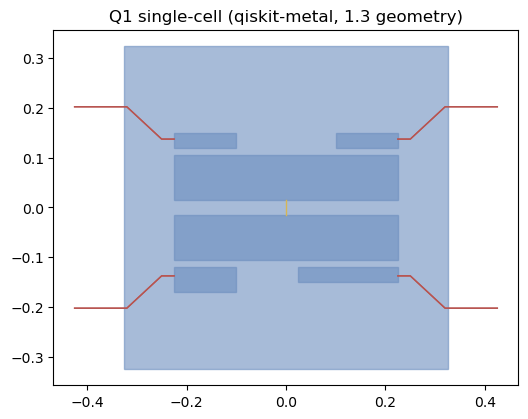

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
tables = design.qgeometry.tables
for name, color in [("poly", "#6c8ebf"), ("path", "#b85450"), ("junction", "#d6b656")]:
    if name not in tables:
        continue
    for _, row in tables[name].iterrows():
        g = row["geometry"]
        if g is None:
            continue
        if g.geom_type == "LineString":
            ax.plot(*g.xy, color=color, lw=1)
        else:
            for p in (g.geoms if g.geom_type == "MultiPolygon" else [g]):
                ax.fill(*p.exterior.xy, color=color, alpha=0.6)
ax.set_aspect("equal")
ax.set_title("Q1 single-cell (qiskit-metal, 1.3 geometry)")
fig.savefig("qm4q_transmon_cell_ref.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Elmer renderer + 网格(min 5µm / max 50µm)

**这一步在算什么?** `QElmerRenderer` 把上面的 2D 版图"立"成一个 3D 电磁场问题:把每片金属当成
一个**导体电极**,芯片衬底(硅,ε_r=11.45)当介质,外面罩一个真空盒。`QGmshRenderer` 先把这个
3D 区域剖成四面体网格(`min 5µm / max 50µm` 控制疏密)。

`box_plus_buffer=True` + `x/y_buffer=0.2mm`(默认)→ 地平面 = 器件 bbox + 每边 0.2mm =
**1250×1050µm**,与参考几何一致。`skip_junctions=True`:JJ 不当导体进网格。

In [ ]:
elmer = QElmerRenderer(design)
elmer.gmsh.options.mesh.min_size = "5um"
elmer.gmsh.options.mesh.max_size = "50um"

elmer.render_design(
    open_pins=[("Q1", "a"), ("Q1", "b"), ("Q1", "c"), ("Q1", "d")],
    skip_junctions=True,
)
elmer.export_mesh()

Info    : Clearing all models and views...
Info    : Done clearing all models and views


Info    : Meshing 1D...
Info    : [  0%] Meshing curve 147 (Line)
Info    : [  0%] Meshing curve 146 (Line)
Info    : [  0%] Meshing curve 151 (Line)
Info    : [  0%] Meshing curve 150 (Line)
Info    : [  0%] Meshing curve 152 (Line)
Info    : [  0%] Meshing curve 148 (Line)
Info    : [  0%] Meshing curve 145 (Line)
Info    : [ 10%] Meshing curve 153 (Line)
Info    : [ 10%] Meshing curve 154 (Line)
Info    : [ 10%] Meshing curve 155 (Line)
Info    : [ 10%] Meshing curve 156 (Line)
Info    : [  0%] Meshing curve 149 (Line)
Info    : [ 10%] Meshing curve 157 (Line)
Info    : [ 10%] Meshing curve 158 (Line)
Info    : [ 10%] Meshing curve 159 (Line)
Info    : [ 10%] Meshing curve 160 (Line)
Info    : [ 10%] Meshing curve 161 (Line)
Info    : [ 10%] Meshing curve 162 (Line)
Info    : [ 10%] Meshing curve 163 (Line)
Info    : [ 10%] Meshing curve 164 (Line)
Info    : [ 10%] Meshing curve 165 (Line)
Info    : [ 10%] Meshing curve 166 (Line)
Info    : [ 10%] Meshing curve 167 (Line)
Info    : 

Info    : [ 80%] Meshing curve 411 (Line)
Info    : [ 80%] Meshing curve 412 (Line)
Info    : [ 80%] Meshing curve 413 (Line)
Info    : [ 80%] Meshing curve 414 (Line)
Info    : [ 80%] Meshing curve 415 (Line)
Info    : [ 80%] Meshing curve 416 (Line)
Info    : [ 80%] Meshing curve 417 (Line)
Info    : [ 80%] Meshing curve 418 (Line)
Info    : [ 80%] Meshing curve 419 (Line)
Info    : [ 80%] Meshing curve 420 (Line)
Info    : [ 80%] Meshing curve 421 (Line)
Info    : [ 80%] Meshing curve 422 (Line)
Info    : [ 80%] Meshing curve 423 (Line)
Info    : [ 80%] Meshing curve 424 (Line)
Info    : [ 80%] Meshing curve 425 (Line)
Info    : [ 80%] Meshing curve 426 (Line)
Info    : [ 80%] Meshing curve 427 (Line)
Info    : [ 80%] Meshing curve 428 (Line)
Info    : [ 80%] Meshing curve 429 (Line)
Info    : [ 80%] Meshing curve 430 (Line)
Info    : [ 80%] Meshing curve 431 (Line)
Info    : [ 90%] Meshing curve 432 (Line)
Info    : [ 90%] Meshing curve 433 (Line)
Info    : [ 90%] Meshing curve 434

Info    : [ 20%] Meshing surface 98 (Plane, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 99 (Plane, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 100 (Plane, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 101 (Plane, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 102 (Plane, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 103 (Plane, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 104 (Plane, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 105 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 106 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 107 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 108 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 109 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 110 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 111 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 112 (Plane, Frontal-Delaunay)
Info    : [ 30%] Meshing surface 113 (Plane, Frontal-Dela

Info    : [ 70%] Meshing surface 161 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 162 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 163 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 164 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 165 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 166 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 167 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 168 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 169 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 170 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 171 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 172 (Plane, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 173 (Plane, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 174 (Plane, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 175 (Plane, Frontal-Delaunay)
Info    : [ 80%] Meshing surface 176 (Plane, Frontal-De

...

Info    : Improving      33045 tet. on   8 thrd (S & ER)
Info    : Improving      33044 tet. on   8 thrd (S & ER)
Info    : Improving      33044 tet. on   8 thrd (S & ER)
Info    : Improving      33044 tet. on   8 thrd (GSC)


Info    : Improving      33039 tet. on   8 thrd (S & ER)
Info    : Improving      33038 tet. on   8 thrd (S & ER)
Info    : Improving      33038 tet. on   8 thrd (GSC)


Info    : Improving      33038 tet. on   8 thrd (S & ER)
Info    :  	Final tet. mesh contains 675131 tetrahedra
Info    :  	Final tet. mesh contains 114542 vertices
Info    : tEmptyMesh  	 = 	    0.158
Info    : tVerifyBnd  	 = 	    0.009
Info    : tBndRecovery	 = 	    0.613
Info    : tConvertMesh	 = 	    0.027
Info    : tRefine     	 = 	    1.082
Info    : tOptimize   	 = 	    5.708
Info    : Done meshing 3D (Wall 7.73023s, CPU 36.9788s)
Info    : 114542 nodes 771336 elements


Info    : Writing 'out.msh'...


Info    : Done writing 'out.msh'


## 4. 求解 7×7 电容矩阵(Elmer `StatElecSolver`)

**Elmer 静电求解在算什么?** 它逐个把某一片导体加 1V、其余接地,解整个区域的静电场(拉普拉斯方程),
再从电场能量反推出**每对导体之间存了多少电荷 / 多少电容**。6 片导体两两组合 + 各自对地,
凑成一张 **7×7 Maxwell 电容矩阵**(单位 fF):
- **对角** = 自电容(该导体对所有其它导体+地的总电容);
- **非对角** = 两导体间的互容(按惯例取负值)。

6 个导体 = `pad_top`、`pad_bot`、`a/b/c/d connector_pad`;第 7 行/列是 `ground_plane` 参考
(真空盒外壁用 FarField 边界条件)。

In [ ]:
elmer.add_solution_setup("capacitance")
elmer.run("capacitance")          # 调 ElmerGrid + ElmerSolver,约数分钟
cap = elmer.capacitance_matrix    # pandas DataFrame, fF
cap.round(2)

02:47AM 06s INFO [run]: Running ElmerGrid on input mesh from Gmsh...


02:47AM 06s INFO [run]: Running ElmerSolver for solver type: 'capacitance'


,Q1_a_connector_pad,Q1_b_connector_pad,Q1_c_connector_pad,Q1_d_connector_pad,Q1_pad_top,Q1_pad_bot,ground_plane
Q1_a_connector_pad,63.46,-0.41,-0.52,-0.19,-16.62,-1.69,-44.03
Q1_b_connector_pad,-0.41,63.42,-0.23,-0.48,-16.53,-1.70,-44.07
Q1_c_connector_pad,-0.52,-0.23,75.11,-0.97,-2.28,-23.66,-47.46
Q1_d_connector_pad,-0.19,-0.48,-0.97,67.38,-1.94,-17.48,-46.32
Q1_pad_top,-16.62,-16.53,-2.28,-1.94,109.96,-36.06,-36.53
Q1_pad_bot,-1.69,-1.70,-23.66,-17.48,-36.06,114.85,-34.26
ground_plane,-44.03,-44.07,-47.46,-46.32,-36.53,-34.26,300.00


In [ ]:
elmer.save_capacitance_matrix("elmer_cap_matrix.txt")
elmer.close()
print("saved:", OUT / "elmer_cap_matrix.txt")

Info    : Clearing all models and views...
Info    : Done clearing all models and views
saved: /home/administrator/quantum_dsl/build/qm4q_elmer_ref_nb/elmer_cap_matrix.txt


## 5. 被求解的电路:等效电容网络

上面这张 7×7 矩阵,物理上就等价于下面这张**电容网络**:6 片金属是 6 个节点,地是参考节点;
每个节点对地挂一个电容(矩阵对角,自电容),关系密切的两片金属之间再挂一个互容(矩阵非对角)。
这正是 Elmer 静电那一步真正"解出来"的电路 —— 后续 LOM(集总振子模型)就拿这些电容值当参数。

读图:
- **`pad_top` / `pad_bot`** 是 transmon 的两片岛,中间那条虚线是 **JJ(集总,不进静电求解)**,
  它们之间的互容(≈36 fF)就是 qubit 的主电容;
- **`a,b` 接上岛(`pad_top`)、`c,d` 接下岛(`pad_bot`)** —— 由 1.3 里 4 个 pad 的
  `loc_H` 上/下决定;这些互容就是 qubit 到各读出/耦合线的耦合电容;
- 每个节点向下到那条横线(地)的电容,是该导体对地的自电容。

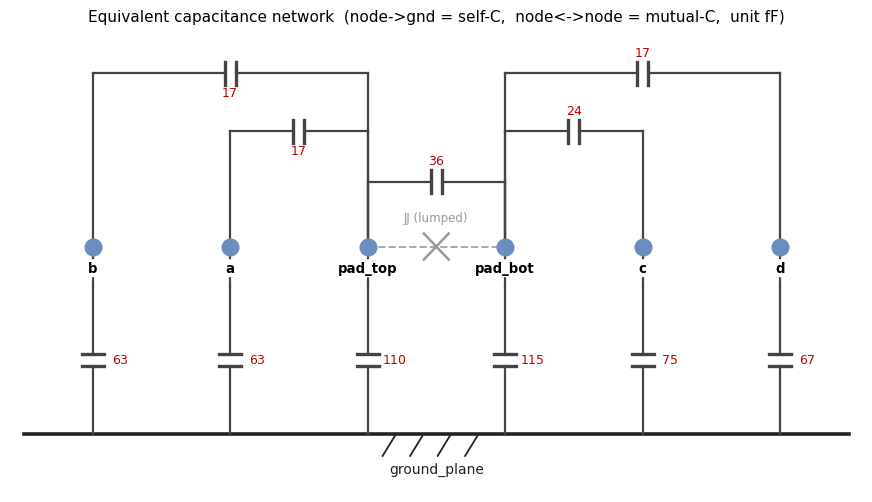

In [ ]:
# 用刚解出的 cap 矩阵画一张等效电容网络示意图(横排,6 节点各自独立对地,避免连线交叠)
# 图内文字一律用 ASCII,绕开 matplotlib 默认字体缺中文字形(否则显示成豆腐块)
def draw_cap(ax, p1, p2, label, plate=0.16, gap=0.16, color="#444", lw=1.6, loff=0.30):
    p1 = np.asarray(p1, float); p2 = np.asarray(p2, float)
    d = p2 - p1; L = np.hypot(*d); u = d / L; n = np.array([-u[1], u[0]])
    m = (p1 + p2) / 2; a = m - u * gap / 2; b = m + u * gap / 2
    ax.plot([p1[0], a[0]], [p1[1], a[1]], color=color, lw=lw)
    ax.plot([b[0], p2[0]], [b[1], p2[1]], color=color, lw=lw)
    for q in (a, b):
        ax.plot([q[0]-n[0]*plate, q[0]+n[0]*plate], [q[1]-n[1]*plate, q[1]+n[1]*plate],
                color=color, lw=2.4)
    ax.annotate(label, m + n*loff, ha="center", va="center", fontsize=9, color="#b00")

mat = {"pad_top": "Q1_pad_top", "pad_bot": "Q1_pad_bot", "a": "Q1_a_connector_pad",
       "b": "Q1_b_connector_pad", "c": "Q1_c_connector_pad", "d": "Q1_d_connector_pad"}
def cval(i, j): return abs(cap.loc[mat[i], mat[j]])    # 互容幅值 fF
def cself(i):   return cap.loc[mat[i], mat[i]]         # 自电容 fF

X = {"b": -5, "a": -3, "pad_top": -1, "pad_bot": 1, "c": 3, "d": 5}   # 横排位置
GND = -2.6

fig2, ax = plt.subplots(figsize=(11, 6)); ax.axis("off")
ax.set_xlim(-6.2, 6.2); ax.set_ylim(-3.4, 3.0)

# 地平面 + 地符号
ax.plot([-6, 6], [GND, GND], color="#222", lw=2.6)
for gx in np.linspace(-0.6, 0.6, 4):
    ax.plot([gx, gx-0.18], [GND-0.02, GND-0.30], color="#222", lw=1.3)
ax.annotate("ground_plane", (0, GND-0.55), ha="center", fontsize=10, color="#222")

# 每个节点:对地自电容(向下)+ 圆点 + 名字
for k, x in X.items():
    ax.plot([x, x], [0, -0.55], color="#444", lw=1.6)
    draw_cap(ax, (x, -0.55), (x, GND), f"{cself(k):.0f}", loff=0.40)
    ax.plot(x, 0, "o", ms=12, color="#6c8ebf", zorder=4)
    ax.annotate(k, (x, -0.30), ha="center", va="center", fontsize=9.5, weight="bold",
                zorder=5, bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none"))

# 互容:节点 i 竖直上引到高度 h,水平接到节点 j(电容画在水平段),错开高度防交叠
def mutual(i, j, h):
    xi, xj = X[i], X[j]
    ax.plot([xi, xi], [0, h], color="#444", lw=1.6)
    ax.plot([xj, xj], [0, h], color="#444", lw=1.6)
    draw_cap(ax, (xi, h), (xj, h), f"{cval(i, j):.0f}", loff=0.28)

mutual("pad_top", "pad_bot", 0.9)
mutual("pad_top", "a", 1.6)
mutual("pad_bot", "c", 1.6)
mutual("pad_top", "b", 2.4)
mutual("pad_bot", "d", 2.4)

# JJ:pad_top--pad_bot 之间(集总元件,不进静电求解),基线上画虚线 + 叉号
ax.plot([X["pad_top"], X["pad_bot"]], [0, 0], ls="--", color="#aaa", lw=1.4, zorder=1)
ax.plot([-0.18, 0.18], [-0.18, 0.18], color="#999", lw=1.8, zorder=2)
ax.plot([-0.18, 0.18], [0.18, -0.18], color="#999", lw=1.8, zorder=2)
ax.annotate("JJ (lumped)", (0, 0.34), ha="center", fontsize=8.5, color="#999")

ax.set_title("Equivalent capacitance network  "
             "(node->gnd = self-C,  node<->node = mutual-C,  unit fF)", fontsize=11)
fig2.savefig("qm4q_cap_network.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 与已有参考核对

参考关键值(fF,`build/qm4q_elmer_ref/elmer_cap_matrix.txt`):
自电容 `pad_top 109.8 / pad_bot 114.6 / a,b,c,d 63.3/63.5/74.9/67.3`;
互容 `pad_top–pad_bot −36.0`、`a–pad_top −16.5`、`c–pad_bot −23.6`。
本 notebook 重跑应与之吻合(微小差异来自网格随机性)。

In [ ]:
diag = lambda m: pd.Series({n: m.loc[n, n] for n in m.index}).round(2)

print("=== 本次求解:对角(自电容, fF) ===")
print(diag(cap))

if REF.exists():
    ref = load_capacitance_matrix_from_file(str(REF))
    print("\n=== 已有参考 build/qm4q_elmer_ref:对角(自电容, fF) ===")
    print(diag(ref))
    print("\n=== 关键互容对照(fF) ===")
    for a, b in [("Q1_pad_top", "Q1_pad_bot"),
                 ("Q1_a_connector_pad", "Q1_pad_top"),
                 ("Q1_c_connector_pad", "Q1_pad_bot")]:
        print(f"{a:22s} {b:18s} 本次={cap.loc[a, b]:8.2f}  参考={ref.loc[a, b]:8.2f}")
else:
    print("\n(未找到已有参考文件,跳过对照)")

=== 本次求解:对角(自电容, fF) ===
Q1_a_connector_pad     63.46
Q1_b_connector_pad     63.42
Q1_c_connector_pad     75.11
Q1_d_connector_pad     67.38
Q1_pad_top            109.96
Q1_pad_bot            114.85
ground_plane          300.00
dtype: float64

=== 已有参考 build/qm4q_elmer_ref:对角(自电容, fF) ===
Q1_a_connector_pad     63.30
Q1_b_connector_pad     63.49
Q1_c_connector_pad     74.91
Q1_d_connector_pad     67.29
Q1_pad_top            109.81
Q1_pad_bot            114.64
ground_plane          300.00
dtype: float64

=== 关键互容对照(fF) ===
Q1_pad_top             Q1_pad_bot         本次=  -36.06  参考=  -35.96
Q1_a_connector_pad     Q1_pad_top         本次=  -16.62  参考=  -16.51
Q1_c_connector_pad     Q1_pad_bot         本次=  -23.66  参考=  -23.62
